# Joint Recurrence Plots Analysis - Lag Synchronization

## Samuel Jaramillo

### Research question
1. Compare the recurrence plot methods for detecting phase, generalised, and complete synchronisation (lag synchronisation is included).

2. Prepare an overview of the ability of the measures derived from cross- and joint recurrence plots and from tau-recurrence rate.

3. (Bonus) improve the tau-recurrence rate measure (CPR).

In [1]:
import numpy as np
import pandas as pd
import recurrence as rec
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.integrate import solve_ivp
import string
from tqdm import tqdm

# we can use the pyunicorn classes for all types of recurrence plots for convenience
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

In [2]:
#Import models
nosynch1 = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/timeseries/LS_nosynch1.csv').to_numpy()

nosynch2 = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/timeseries/LS_nosynch2.csv').to_numpy()

synch1 = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/timeseries/LS_synch1.csv').to_numpy()

synch2 = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/timeseries/LS_synch2.csv').to_numpy()

In [3]:
#View the individual recurrence plots
#No synch
rec_nosynch1 = RecurrencePlot(nosynch1, recurrence_rate=0.1, metric="euclidean")
rm_nosynch1 = rec_nosynch1.recurrence_matrix()

rec_nosynch2 = RecurrencePlot(nosynch2, recurrence_rate=0.1, metric="euclidean")
rm_nosynch2 = rec_nosynch2.recurrence_matrix()

#Synch
rec_synch1 = RecurrencePlot(synch1, recurrence_rate=0.1, metric="euclidean")
rm_synch1 = rec_synch1.recurrence_matrix()

rec_synch2 = RecurrencePlot(synch2, recurrence_rate=0.1, metric="euclidean")
rm_synch2 = rec_synch2.recurrence_matrix()

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


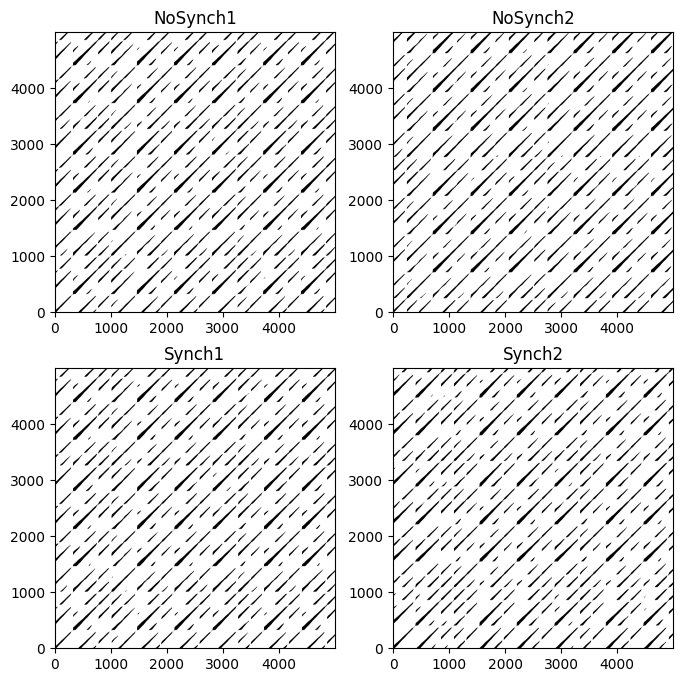

In [4]:
#Visualize
fig, axs = plt.subplots(2,2,figsize=(8, 8))

#Plot
RP_comparison_list = [rm_nosynch1, rm_nosynch2, rm_synch1, rm_synch2]
RP_comparison_titles = ['NoSynch1', 'NoSynch2', 'Synch1', 'Synch2']

l = 0
for i in range(2):
    for j in range(2):
        axs[i][j].imshow(RP_comparison_list[l], origin='lower', cmap = 'binary')
        axs[i][j].set_title(RP_comparison_titles[l])

        l += 1

plt.show()

In [5]:
#Compute JRPs
#No synch
LS_JR_nosynch = JointRecurrencePlot(nosynch1, nosynch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"))

RMat_LS_nosynch = LS_JR_nosynch.recurrence_matrix()

#Synch
LS_JR_synch = JointRecurrencePlot(synch1, synch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"))

RMat_LS_synch = LS_JR_synch.recurrence_matrix()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...


In [6]:
#Find lag with max S(tau)
lagged_JR_synch = [JointRecurrencePlot(synch1, synch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = i) for i in range(120)]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

In [7]:
s_tau_synch = [lagged_JR_synch[i].recurrence_rate()/0.1 for i in range(len(lagged_JR_synch))]

In [8]:
max_lag = np.where(np.array(s_tau_synch) == max(s_tau_synch))[0][0]

max_JRP_tau = lagged_JR_synch[max_lag]

RMat_max_JRP_tau  = max_JRP_tau.recurrence_matrix()

In [9]:
#Print S(tau) values for non-synched, synched and max synched models
print('JRP NoSynch', LS_JR_nosynch.recurrence_rate()/0.1)
print('JRP(0)',s_tau_synch[0])
print('JRP(tau)',max(s_tau_synch))

JRP NoSynch 0.281976
JRP(0) 0.6202632
JRP(tau) 0.8632196


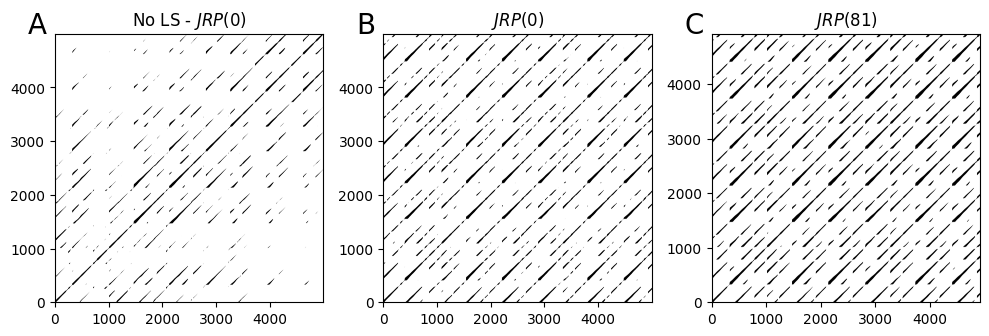

In [ ]:
#Visualize
fig, axs = plt.subplots(1,3,figsize=(10, 4))

axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title(r'No LS - $JRP(0)$')
axs[0].text(-0.1, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title(r'$JRP(0)$')
axs[1].text(-0.1, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)

axs[2].imshow(RMat_max_JRP_tau, origin='lower', cmap = 'binary')
axs[2].set_title(r'$JRP({})$'.format(max_lag))
axs[2].text(-0.1, 1, string.ascii_uppercase[2], transform=axs[2].transAxes, 
            size=20)


plt.tight_layout()

plt.show()
#fig.savefig('plots/JRPs_LS.pdf', dpi=300)

Evaluation of sensitivity of $S(\tau)$ to coupling

In [11]:
#Import model
def coupled_rossler_delay(a=0.2, b=0.2, c=5.7,
                         k=0.5, tau=2.0,
                         dt=0.01, steps=10000):

    import numpy as np

    delay_steps = int(tau / dt)

    # initialize arrays
    xd = np.zeros(steps)
    yd = np.zeros(steps)
    zd = np.zeros(steps)

    xr = np.zeros(steps)
    yr = np.zeros(steps)
    zr = np.zeros(steps)

    # initial conditions
    xd[0], yd[0], zd[0] = 1, 1, 1
    xr[0], yr[0], zr[0] = 0, 0, 0

    for i in range(steps - 1):

        # drive
        xd[i+1] = xd[i] + dt * (-yd[i] - zd[i])
        yd[i+1] = yd[i] + dt * (xd[i] + a * yd[i])
        zd[i+1] = zd[i] + dt * (b + zd[i] * (xd[i] - c))

        # delayed signal
        if i > delay_steps:
            xd_tau = xd[i - delay_steps]
        else:
            xd_tau = xd[0]

        # response
        xr[i+1] = xr[i] + dt * (-yr[i] - zr[i] + k * (xd_tau - xr[i]))
        yr[i+1] = yr[i] + dt * (xr[i] + a * yr[i])
        zr[i+1] = zr[i] + dt * (b + zr[i] * (xr[i] - c))
    
    driver = np.array([xd, yd, zd])
    response = np.array([xr, yr, zr])

    return driver, response

In [12]:
#Coupling values to be used
ks = np.linspace(0, 0.5, 40)

The code block below was used to compute the JPR values for the different coupling values. Due to the time it took to compute, we import directly the result and leave the code inside quotation marks.

In [13]:
'''
from tqdm import tqdm

JPR_list = []


for i in tqdm(range(len(ks))):
    d, r = coupled_rossler_delay(dt = 0.025, k=ks[i])

    d = d.T[5000:]
    r = r.T[5000:]

    #Vary lag to cover wider range
    lagged_JR_synch_i = [JointRecurrencePlot(d, r, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = 3*j) for j in range(30)]
    s_tau_synch_i = np.array([lagged_JR_synch_i[k].recurrence_rate()/0.1 for k in range(len(lagged_JR_synch_i))])


    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)

    JPR_list.append(JPR_i)
'''

'\nfrom tqdm import tqdm\n\nJPR_list = []\n\n\nfor i in tqdm(range(len(ks))):\n    d, r = coupled_rossler_delay(dt = 0.025, k=ks[i])\n\n    d = d.T[5000:]\n    r = r.T[5000:]\n\n    #Vary lag to cover wider range\n    lagged_JR_synch_i = [JointRecurrencePlot(d, r, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = 3*j) for j in range(30)]\n    s_tau_synch_i = np.array([lagged_JR_synch_i[k].recurrence_rate()/0.1 for k in range(len(lagged_JR_synch_i))])\n\n\n    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)\n\n    JPR_list.append(JPR_i)\n'

In [14]:
'''
#Save to avoid computing it again
JPR_list_saved = pd.DataFrame(JPR_list)

# save the dataframe as a csv file
JPR_list_saved.to_csv("LS_JPR_list.csv", index=False)
'''

'\n#Save to avoid computing it again\nJPR_list_saved = pd.DataFrame(JPR_list)\n\n# save the dataframe as a csv file\nJPR_list_saved.to_csv("LS_JPR_list.csv", index=False)\n'

In [15]:
#Import models
JPR_list = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/LS_JPR_list.csv').to_numpy()

In [16]:
#Compute CPR values for varying couplings
CPR_list = []

for i in tqdm(range(len(ks))):
    d, r = coupled_rossler_delay(dt = 0.025, k=ks[i])

    d = d.T[5000:]
    r = r.T[5000:]

    rp_drive = RecurrencePlot(d, metric="euclidean", recurrence_rate=0.1)
    rp_response = RecurrencePlot(r, metric="euclidean", recurrence_rate=0.1)

    RP_drive = rp_drive.recurrence_matrix()
    RP_response = rp_response.recurrence_matrix()

    C = rec.cpr(RP_drive, RP_response)

    CPR_list.append(C)

  0%|          | 0/40 [00:00<?, ?it/s]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


  2%|▎         | 1/40 [00:04<02:48,  4.33s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


  5%|▌         | 2/40 [00:08<02:44,  4.33s/it]

...

 95%|█████████▌| 38/40 [02:41<00:08,  4.22s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


 98%|█████████▊| 39/40 [02:45<00:04,  4.21s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


100%|██████████| 40/40 [02:49<00:00,  4.25s/it]


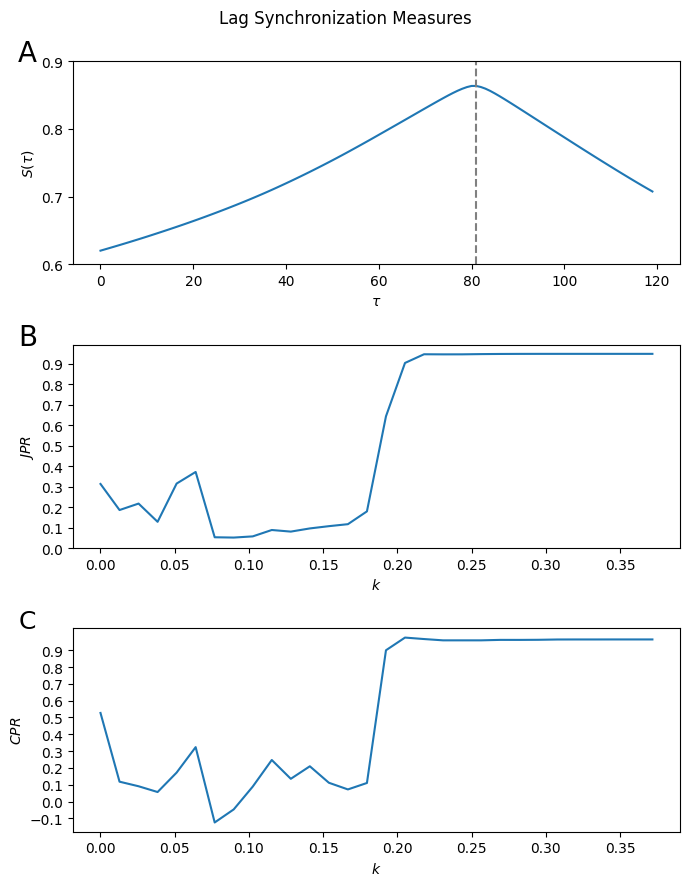

In [17]:
#Lag Synchronization Measures Plot
fig, axs = plt.subplots(3,1,figsize=(7, 9))

#S tau
axs[0].plot(s_tau_synch)
axs[0].set_xlabel(r'$\tau$')
axs[0].set_ylabel(r'$S(\tau)$')
axs[0].set_yticks(np.arange(0.6,0.9,0.1))
axs[0].axvline(max_lag, ls = '--', color = 'gray')
axs[0].text(-0.09, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

#JPR
axs[1].plot(ks[:-10],JPR_list[:-10])
axs[1].set_xlabel(r"$k$")
axs[1].set_yticks(np.arange(0,1,0.1))
axs[1].set_xticks(np.arange(0,0.4,0.05))
axs[1].set_ylabel(r"$JPR$")
axs[1].text(-0.09, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)


#CPR
axs[2].plot(ks[:-10],CPR_list[:-10])
axs[2].set_xlabel(r"$k$")
axs[2].set_yticks(np.arange(-0.1,1,0.1))
axs[2].set_xticks(np.arange(0,0.4,0.05))
axs[2].set_ylabel(r"$CPR$")
axs[2].text(-0.09, 1, string.ascii_uppercase[2], transform=axs[2].transAxes, 
            size=18)

fig.suptitle('Lag Synchronization Measures')

plt.tight_layout()
plt.show()


#fig.savefig('plots/LS_JPRandCPR.pdf', dpi=300)